## Assignment 09-10 About OCR Program

Create an OCR program using the MNIST dataset

Program expectations:

The program can detect several numbers in the image
From several numbers in the image, the program can identify each number in the image one by one.
Example:

There is an image of the number 73. When this image is used as input, the output from the program is a list of numbers in the image (ex: [7,3])


<img src="73.png" alt="numbers program for OCR Programs">

---

In [8]:
! pip install keras

In [9]:
from keras.datasets import mnist

(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 12s 1us/step


In [10]:
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [11]:
x_train.shape

(60000, 28, 28)

In [12]:
single_image = x_train[0]

In [13]:
single_image

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

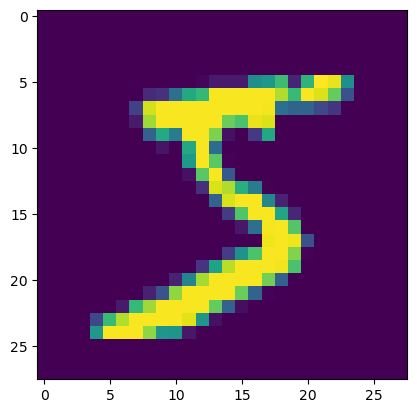

In [16]:
plt.imshow(single_image)

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist

# Load the dataset
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize the images
x_train, x_test = x_train / 255.0, x_test / 255.0

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

# Build the model
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

In [ ]:
import cv2
import numpy as np

def preprocess_image(image_path):
    # Load the image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    # Resize the image to 28x28 pixels
    image = cv2.resize(image, (28, 28))
    # Normalize the image
    image = image / 255.0
    # Expand dimensions to match the input shape of the model
    image = np.expand_dims(image, axis=-1)
    return image

In [ ]:
def segment_image(image_path):
    # Load the image
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    # Threshold the image
    _, thresh = cv2.threshold(image, 128, 255, cv2.THRESH_BINARY_INV)
    # Find contours
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # Extract bounding boxes
    bounding_boxes = [cv2.boundingRect(contour) for contour in contours]
    return bounding_boxes

In [ ]:
def predict_digits(image_path, model):
    bounding_boxes = segment_image(image_path)
    predictions = []
    for box in bounding_boxes:
        x, y, w, h = box
        digit_image = preprocess_image(image_path[y:y+h, x:x+w])
        digit_image = np.expand_dims(digit_image, axis=0)
        prediction = model.predict(digit_image)
        predicted_digit = np.argmax(prediction)
        predictions.append(predicted_digit)
    return predictions

# Example usage
image_path = '73.png'
predictions = predict_digits(image_path, model)
print(predictions)